In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as sp_stats
from scipy.optimize import curve_fit

plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
df = pd.read_csv('../../Data/Figures_2-3-4/constructs_df.csv', index_col=0)

In [3]:
# remove rows where 'construct' contains "GS" (case-insensitive)
mask_gs = df['construct'].astype(str).str.contains('GS', case=False, na=False)
removed = mask_gs.sum()
if removed:
    df = df.loc[~mask_gs].copy()

In [4]:
df['construct'] = df['construct'].astype(int)

<>:81: SyntaxWarning: invalid escape sequence '\e'
<>:81: SyntaxWarning: invalid escape sequence '\e'
/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_71255/4177599140.py:81: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$\epsilon$')


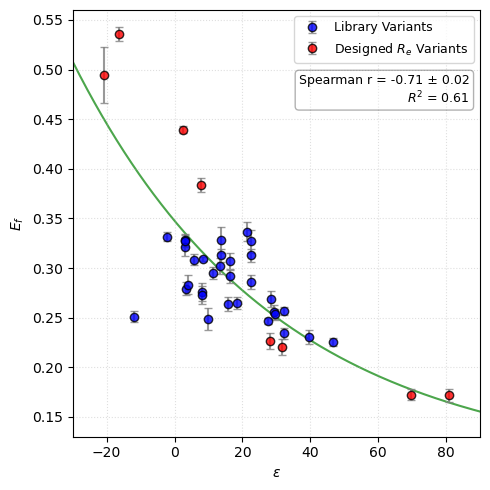

In [ ]:
# plot calvados_epsilon vs Ef_cell with error bars
mask = df[['Ef_cell', 'Ef_cell_std', 'calvados_epsilon']].notnull().all(axis=1)
plot_df = df.loc[mask]

x = plot_df['calvados_epsilon']
y = plot_df['Ef_cell']
yerr = plot_df['Ef_cell_std']

# Create color array based on construct number
colors = ['red' if construct >= 35 and construct <= 42 else 'blue' for construct in plot_df['construct']]

fig, ax = plt.subplots(figsize=(5, 5))

# Plot points with separate calls for legend
blue_plotted = False
red_plotted = False
for i, (xi, yi, yerri, color) in enumerate(zip(x, y, yerr, colors)):
    label = None
    if color == 'blue' and not blue_plotted:
        label = 'Library Variants'
        blue_plotted = True
    elif color == 'red' and not red_plotted:
        label = 'Designed $R_e$ Variants'
        red_plotted = True
    
    ax.errorbar(xi, yi, yerr=yerri, fmt='o', color=color, 
                markeredgecolor='black', markeredgewidth=1,
                ecolor='grey', capsize=3, alpha=0.8, label=label)

# Monte Carlo sampling for Spearman correlation
n_iterations = 1000
spearman_values = []

for _ in range(n_iterations):
    sampled_y = []
    
    for idx, row in plot_df.iterrows():
        # Sample from normal distribution for Ef_cell only
        sampled_y_val = np.random.normal(row['Ef_cell'], row['Ef_cell_std'])
        sampled_y.append(sampled_y_val)
    
    # Calculate Spearman correlation across all constructs for this iteration
    if len(sampled_y) == len(plot_df):  # Ensure we have all constructs
        spearman_r_sample, _ = sp_stats.spearmanr(x, sampled_y)
        spearman_values.append(spearman_r_sample)

# Calculate mean and std of Spearman correlations
spearman_r_mean = np.mean(spearman_values)
spearman_r_std = np.std(spearman_values)

# Fit shifted exponential decay: y = a*e^(-k*(x-x0)) + c
def shifted_exp_decay(x, a, k, x0, c):
    return a * np.exp(-k * (x - x0)) + c

# Initial guesses for shifted exponential decay
popt, pcov = curve_fit(shifted_exp_decay, x, y, 
                       p0=[np.max(y) - np.min(y), 0.05, np.min(x), 0], 
                       bounds=([0, 0, -np.inf, 0], [np.inf, np.inf, np.inf, .1]),
                       maxfev=10000)
a_fit, k_fit, x0_fit, c_fit = popt

# Set x-axis limits
ax.set_xlim(-30, 90)

# Get x-axis limits and create smooth curve for calvados_epsilon
x_limits = ax.get_xlim()
line_x = np.linspace(x_limits[0], x_limits[1], 1000)
line_y = shifted_exp_decay(line_x, a_fit, k_fit, x0_fit, c_fit)

# Plot fitted curve
ax.plot(line_x, line_y, color='green', linestyle='-', linewidth=1.5, alpha=0.7, zorder=1)

# Calculate R² for the fit
y_pred = shifted_exp_decay(x, a_fit, k_fit, x0_fit, c_fit)
residuals = y - y_pred
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)

ax.set_ylim(.13, .56)
ax.set_xlabel('$\epsilon$')
ax.set_ylabel('$E_{f}$')
ax.grid(True, linestyle=':', alpha=0.4)

# Add legend to top right
ax.legend(loc='upper right', frameon=True, fontsize=9)
ax.text(0.975, 0.85, f'Spearman r = {spearman_r_mean:.2f} ± {spearman_r_std:.2f}\n$R^2$ = {r_squared:.2f}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.3))

plt.tight_layout()
#plt.savefig('Ef_vs_epsilon_calvados.svg')